# Pizza Place Sales Analysis
- Task 3
- Omoladun Sakirat Adedamola
- Cohort7

In [3]:
import pandas as pd

In [4]:
# loading the datasets

orders = pd.read_csv(r"C:\Users\OMOLADUN LATEEF\Downloads\pizza_sales\orders.csv")

order_details = pd.read_csv(r"C:\Users\OMOLADUN LATEEF\Downloads\pizza_sales\order_details.csv")

pizzas = pd.read_csv(r"C:\Users\OMOLADUN LATEEF\Downloads\pizza_sales\pizzas.csv")

pizza_types = pd.read_csv(r"C:\Users\OMOLADUN LATEEF\Downloads\pizza_sales\pizza_types.csv", encoding="cp1252")

In [5]:
orders.head()

,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


In [6]:
order_details.head()

,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1


In [7]:
pizzas.head()

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


In [8]:
pizza_types.head()

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."


In [9]:
# merging the datasets in a dataframe

df = order_details.merge(orders, on="order_id")
df = df.merge(pizzas, on="pizza_id")
df = df.merge(pizza_types, on="pizza_type_id")

In [10]:
df.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


In [11]:
df.isna().sum()

order_details_id    0
order_id            0
pizza_id            0
quantity            0
date                0
time                0
pizza_type_id       0
size                0
price               0
name                0
category            0
ingredients         0
dtype: int64

In [12]:
df.shape

(48620, 12)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_details_id  48620 non-null  int64  
 1   order_id          48620 non-null  int64  
 2   pizza_id          48620 non-null  str    
 3   quantity          48620 non-null  int64  
 4   date              48620 non-null  str    
 5   time              48620 non-null  str    
 6   pizza_type_id     48620 non-null  str    
 7   size              48620 non-null  str    
 8   price             48620 non-null  float64
 9   name              48620 non-null  str    
 10  category          48620 non-null  str    
 11  ingredients       48620 non-null  str    
dtypes: float64(1), int64(3), str(8)
memory usage: 4.5 MB


In [14]:
#convert date to datetime

df["date"] = pd.to_datetime(df["date"])


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_details_id  48620 non-null  int64         
 1   order_id          48620 non-null  int64         
 2   pizza_id          48620 non-null  str           
 3   quantity          48620 non-null  int64         
 4   date              48620 non-null  datetime64[us]
 5   time              48620 non-null  str           
 6   pizza_type_id     48620 non-null  str           
 7   size              48620 non-null  str           
 8   price             48620 non-null  float64       
 9   name              48620 non-null  str           
 10  category          48620 non-null  str           
 11  ingredients       48620 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(3), str(7)
memory usage: 4.5 MB


# Analysis

In [16]:
#What is the total revenue/sales?
df["quantity"].value_counts()

quantity
1    47693
2      903
3       21
4        3
Name: count, dtype: int64

In [17]:
df["price"].value_counts()

price
20.75    8685
12.00    5600
16.00    4474
16.75    4294
16.50    4040
12.50    3328
20.25    3032
12.75    2507
20.50    1998
18.50    1359
17.95    1273
16.25    1114
10.50    1001
12.25     830
9.75      739
15.25     712
14.75     577
11.00     570
25.50     544
23.65     480
13.25     473
14.50     391
17.50     381
21.00     190
35.95      28
Name: count, dtype: int64

In [18]:
#create a Revenue column
df["Revenue"] = df["quantity"] * df["price"]

In [19]:
#Total Revenue / Sales
total_revenue = df["Revenue"].sum()

In [20]:
total_revenue

np.float64(817860.0499999999)

In [21]:
#Total Quantity Sold
total_quantity =df["quantity"].sum()

In [22]:
total_quantity

np.int64(49574)

In [23]:
#Find the Total Orders
total_orders = df["order_id"].nunique()

In [24]:
total_orders

21350

In [25]:
#How many pizza types did they sell?
total_pizza_types = df["pizza_type_id"].nunique()

In [26]:
total_pizza_types

32

In [27]:
pizza_types.shape

(32, 4)

In [28]:
#Average price of the pizzas
average_price = df["price"].mean()

In [29]:
average_price

np.float64(16.494132044426163)

In [63]:
df["price"].describe()

count    48620.000000
mean        16.494132
std          3.621789
min          9.750000
25%         12.750000
50%         16.500000
75%         20.250000
max         35.950000
Name: price, dtype: float64

In [30]:
#convert time column
df["time"] = pd.to_datetime(df["time"], format="%H:%M:%S")

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_details_id  48620 non-null  int64         
 1   order_id          48620 non-null  int64         
 2   pizza_id          48620 non-null  str           
 3   quantity          48620 non-null  int64         
 4   date              48620 non-null  datetime64[us]
 5   time              48620 non-null  datetime64[us]
 6   pizza_type_id     48620 non-null  str           
 7   size              48620 non-null  str           
 8   price             48620 non-null  float64       
 9   name              48620 non-null  str           
 10  category          48620 non-null  str           
 11  ingredients       48620 non-null  str           
 12  Revenue           48620 non-null  float64       
dtypes: datetime64[us](2), float64(2), int64(3), str(6)
memory usage: 4.8 MB


In [32]:
df["hour"] = df["time"].dt.hour

In [33]:
df["hour"]

0        11
1        11
2        11
3        11
4        11
         ..
48615    21
48616    21
48617    21
48618    22
48619    23
Name: hour, Length: 48620, dtype: int32

In [34]:
#what are the peak hours of sales?
peak_hours = df.groupby("hour")["order_id"].nunique().reset_index(name="total orders").sort_values(by="total orders", ascending=False)


In [35]:
peak_hours

,hour,total orders
3,12,2520
4,13,2455
9,18,2399
8,17,2336
10,19,2009
7,16,1920
11,20,1642
5,14,1472
6,15,1468
2,11,1231


In [36]:
#find the total sales made on each day of the week.which day has the highest sales?
df["day_of_week"] = df["date"].dt.day_name()

In [37]:
df["day_of_week"]

0        Thursday
1        Thursday
2        Thursday
3        Thursday
4        Thursday
           ...   
48615    Thursday
48616    Thursday
48617    Thursday
48618    Thursday
48619    Thursday
Name: day_of_week, Length: 48620, dtype: str

In [38]:
df.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,Revenue,hour,day_of_week
0,1,1,hawaiian_m,1,2015-01-01,1900-01-01 11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25,11,Thursday
1,2,2,classic_dlx_m,1,2015-01-01,1900-01-01 11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00,11,Thursday
2,3,2,five_cheese_l,1,2015-01-01,1900-01-01 11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50,11,Thursday
3,4,2,ital_supr_l,1,2015-01-01,1900-01-01 11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75,11,Thursday
4,5,2,mexicana_m,1,2015-01-01,1900-01-01 11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00,11,Thursday


In [39]:
#Which day of the week is when salesare made the most?
sales_by_day = (df.groupby("day_of_week")["Revenue"].sum().sort_values(ascending=False))

In [40]:
sales_by_day

day_of_week
Friday       136073.90
Thursday     123528.50
Saturday     123182.40
Wednesday    114408.40
Tuesday      114133.80
Monday       107329.55
Sunday        99203.50
Name: Revenue, dtype: float64

# The day of the week with the highest sales is Friday.

In [41]:
# 5 top best selling pizza

top_5_pizzas = df.groupby("name")["quantity"].sum().sort_values(ascending=False).head(5)

In [42]:
top_5_pizzas

name
The Classic Deluxe Pizza      2453
The Barbecue Chicken Pizza    2432
The Hawaiian Pizza            2422
The Pepperoni Pizza           2418
The Thai Chicken Pizza        2371
Name: quantity, dtype: int64

In [43]:
# find the sales made in each month
df["month"]= df["date"].dt.month_name()

In [44]:
df.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,Revenue,hour,day_of_week,month
0,1,1,hawaiian_m,1,2015-01-01,1900-01-01 11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25,11,Thursday,January
1,2,2,classic_dlx_m,1,2015-01-01,1900-01-01 11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00,11,Thursday,January
2,3,2,five_cheese_l,1,2015-01-01,1900-01-01 11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50,11,Thursday,January
3,4,2,ital_supr_l,1,2015-01-01,1900-01-01 11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75,11,Thursday,January
4,5,2,mexicana_m,1,2015-01-01,1900-01-01 11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00,11,Thursday,January


In [45]:
#monthly sales
monthly_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
monthly_sales = (df.groupby("month")["Revenue"].sum().reindex(monthly_order))

In [46]:
monthly_sales

month
January      69793.30
February     65159.60
March        70397.10
April        68736.80
May          71402.75
June         68230.20
July         72557.90
August       68278.25
September    64180.05
October      64027.60
November     70395.35
December     64701.15
Name: Revenue, dtype: float64

# The trends are
* July recorded the highest sales with $72,557.90.
* October recorded the lowest sales with $64,027.60.
* Sales remain fairly stable throughout the year, generally ranging between $64,000 and $73,000.
* There is a slight increase in sales from March to July, peaking in July.
* After July, sales decline in August, September, and October, before recovering in November.
* December is lower than November, so there isn't a strong year-end sales surge in this dataset

In [47]:
#Are there pizza types that are not doing well on the menu?

least_selling_pizzas =( df.groupby("name")["quantity"].sum().sort_values())


In [48]:
least_selling_pizzas.head(10)

name
The Brie Carre Pizza            490
The Mediterranean Pizza         934
The Calabrese Pizza             937
The Spinach Supreme Pizza       950
The Soppressata Pizza           961
The Spinach Pesto Pizza         970
The Chicken Pesto Pizza         973
The Italian Vegetables Pizza    981
The Chicken Alfredo Pizza       987
The Green Garden Pizza          997
Name: quantity, dtype: int64

In [49]:
least_selling_pizzas.tail(10)

name
The Big Meat Pizza              1914
The Southwest Chicken Pizza     1917
The Spicy Italian Pizza         1924
The Sicilian Pizza              1938
The California Chicken Pizza    2370
The Thai Chicken Pizza          2371
The Pepperoni Pizza             2418
The Hawaiian Pizza              2422
The Barbecue Chicken Pizza      2432
The Classic Deluxe Pizza        2453
Name: quantity, dtype: int64

In [50]:
## Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
import warnings
warnings.filterwarnings("ignore")

In [51]:
# sales by day of the week- bar chart

sales_day = sales_by_day.reset_index()




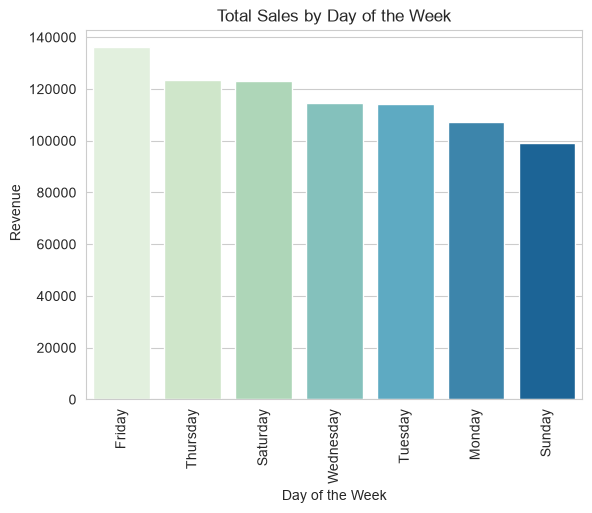

In [52]:
sns.barplot(data=sales_day, x="day_of_week", y="Revenue", palette="GnBu")
plt.title("Total Sales by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel(" Revenue")
plt.xticks(rotation=90)
plt.show()

In [53]:
# Top 5 best selling pizza - bar chart

top5= top_5_pizzas.reset_index()

In [54]:
top5.columns

Index(['name', 'quantity'], dtype='str')

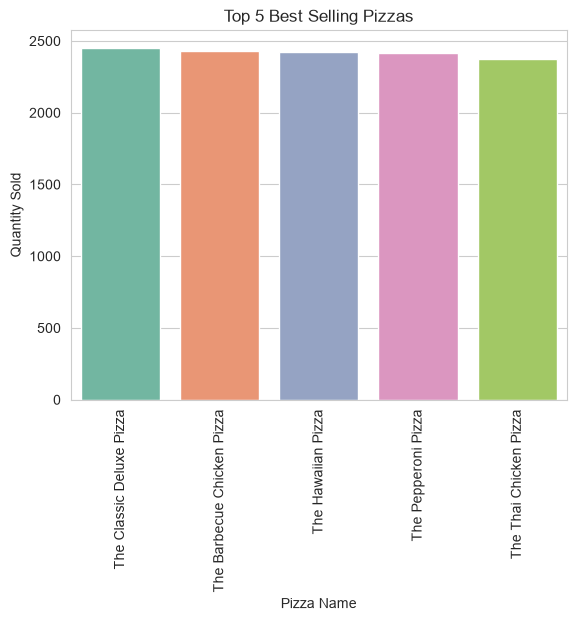

In [55]:
sns.barplot(data=top5, x="name", y="quantity", palette="Set2")
plt.title("Top 5 Best Selling Pizzas")
plt.xlabel("Pizza Name")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=90)
plt.show()

In [56]:
#monthly sales
monthly=monthly_sales.reset_index()

In [57]:
monthly.columns

Index(['month', 'Revenue'], dtype='str')

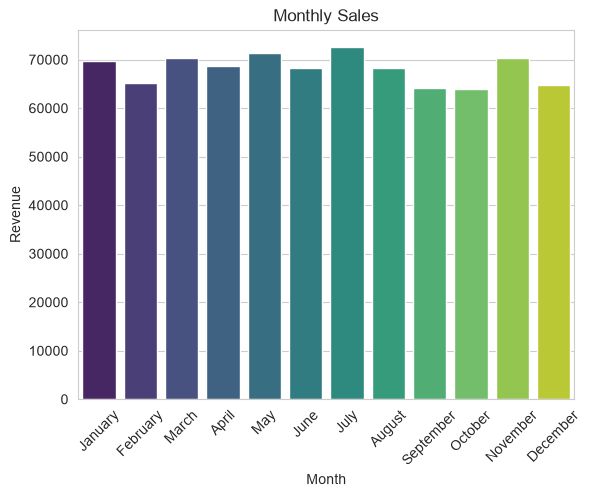

In [58]:
sns.barplot(data=monthly, x="month", y="Revenue", palette="viridis")
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [59]:
#bottom 10 pizzas by revenue
bottom10=least_selling_pizzas.head(10).reset_index()

In [60]:
bottom10.columns

Index(['name', 'quantity'], dtype='str')

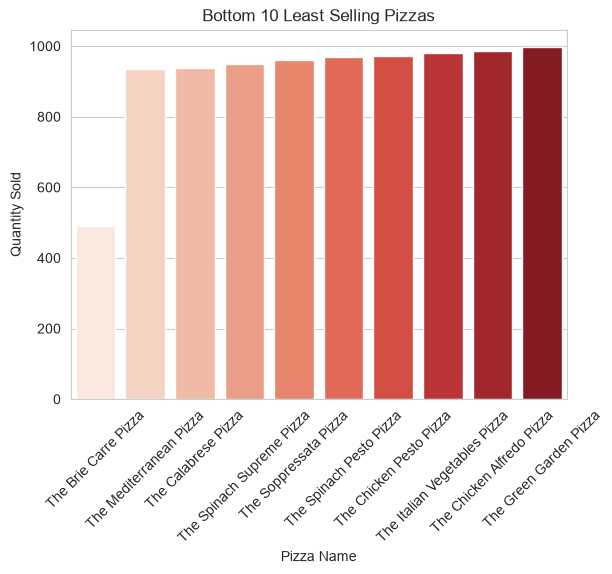

In [61]:
sns.barplot(data=bottom10, x="name", y="quantity", palette="Reds")
plt.title("Bottom 10 Least Selling Pizzas")
plt.xlabel("Pizza Name")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()